# **Graph Metrics (*Density*)**

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path

# algorithms4pepprotgraphs framework
sys.path.append('/home/jovyan/work/algorithms4pepprotgraphs')
from algorithms4pepprotgraphs.module.notebook import NotebookApp
from algorithms4pepprotgraphs.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.AVPDiscover.Ext')
paths = app.paths()

[2025-04-10 23:48:07,974] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/results_with_seq_2_to_100/AVP-external/Log/Sequences with Non-Natural Amino Acids.csv
[2025-04-10 23:48:24,602] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/AVP-external.csv
pdb_path: /home/jovyan/work/algorithms4pepprotgraphs/dataset/AVPDiscover/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/results_with_seq_2_to_100/AVP-external
sequence_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results_with_seq_2_to_100/AVP-external/2025-04-10T21.53.47-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/algorithms4pepprotgraphs/output/results_with_seq_2_to_100/AVP-external/2025-04-10T21.59.42-Graph_Analyzer
min_seq_len: None
max_seq_len: 100


## 📊 **Data Analysis**

### **Data**

In [2]:
# data
data = pd.read_csv(app.graph_analysis['graph_metrics'])
data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)
data = data[["sequence", "distance_interval", "density", "distance_function", "interval"]]

# statistics
statistics = pd.read_csv(
    app.graph_analysis['graph_metrics_summary'].with_name(
        app.graph_analysis['graph_metrics_summary'].name + "-density.csv"
    )
)
statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "density"]].head()

,sequence,distance_interval,density
0,GWFDVVKHIASAV,"euclidean (0, 10.2836)",0.717949
1,FLPLIGKVLSGIL,"euclidean (0, 10.2836)",0.525641
2,FLSLIPHAINAVSTLVHHSG,"euclidean (0, 10.2836)",0.505263
3,GVPCGESCVFIPCITGVIGCSCSSNVCYLN,"euclidean (0, 10.2836)",0.519540
4,GLLSSLSSVAKHVLPHVVPVIAEHL,"euclidean (0, 10.2836)",0.406667


### **Distance Intervals**

In [3]:
display(Markdown("\n".join(f"- {val}" for val in statistics["distance_interval"].unique())))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10.2836)
- euclidean (0, 16.6132)
- euclidean (0, 26.242)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.466)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Analysis of Graph Density Distribution (*all distance intervals*)**

<br>Statistics (*All Distance Intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",20275,0.0,0.277599,0.161002,0.147992,0.231650,0.392372,1.000000,0.757360,2.772130
1,"angular_separation (0, 0.0654)",20275,0.0,0.530915,0.174405,0.384615,0.515071,0.681818,1.000000,0.130876,2.024867
2,"angular_separation (0, 0.1799)",20275,0.0,0.754123,0.119872,0.669175,0.770563,0.847489,1.000000,-0.518979,3.102477
3,"bhattacharyya (0, 1.5158)",20275,0.0,0.286024,0.065410,0.234711,0.286765,0.333333,0.666667,0.097048,2.703761
4,"bhattacharyya (0, 2.4304)",20275,0.0,0.537930,0.085609,0.485714,0.543743,0.594255,1.000000,-0.280338,3.697400
5,"bhattacharyya (0, 3.6452)",20275,0.0,0.776823,0.090969,0.721225,0.784211,0.846154,1.000000,-0.688528,3.818098
6,"canberra (0, 0.6155)",20275,0.0,0.236074,0.080038,0.179487,0.241667,0.294118,0.581633,-0.141713,3.013838
7,"canberra (0, 1.0142)",20275,0.0,0.460451,0.104524,0.397701,0.467836,0.525362,0.792161,-0.377849,3.900975
8,"canberra (0, 1.4712)",20275,0.0,0.690968,0.109509,0.623054,0.679924,0.763216,1.000000,-0.170402,4.119403
9,"clark (0, 0.4161)",20275,0.0,0.240110,0.084857,0.177536,0.242347,0.304762,0.606293,-0.096509,2.755037


<br>Graph Density (*All Distance Intervals*)

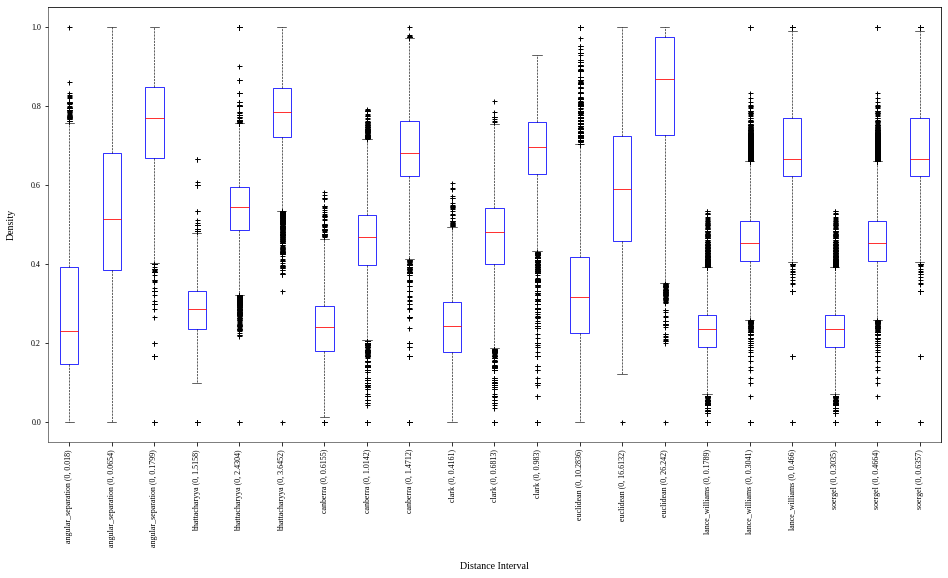

In [4]:
# statistics
display(Markdown("<br>Statistics (*All Distance Intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (all_distance_intervals) -histogram")

fig_size=(16, 8)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Density (*All Distance Intervals*)"))
plt = boxplot(data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Density Distribution (*per Distance Percentile*)**

#### **25th percentile distance intervals**

<br>Statistics (*25th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",20275,0.0,0.277599,0.161002,0.147992,0.231650,0.392372,1.000000,0.757360,2.772130
1,"bhattacharyya (0, 1.5158)",20275,0.0,0.286024,0.065410,0.234711,0.286765,0.333333,0.666667,0.097048,2.703761
2,"canberra (0, 0.6155)",20275,0.0,0.236074,0.080038,0.179487,0.241667,0.294118,0.581633,-0.141713,3.013838
3,"clark (0, 0.4161)",20275,0.0,0.240110,0.084857,0.177536,0.242347,0.304762,0.606293,-0.096509,2.755037
4,"euclidean (0, 10.2836)",20275,0.0,0.341145,0.153752,0.226190,0.315966,0.417582,1.000000,1.085044,4.360608
5,"lance_williams (0, 0.1789)",20275,0.0,0.232138,0.064296,0.190883,0.236782,0.271515,0.535615,-0.034051,4.186576
6,"soergel (0, 0.3035)",20275,0.0,0.232133,0.064294,0.190883,0.236782,0.271506,0.535615,-0.034105,4.186613


<br>Graph Density (*25th percentile distance intervals*)

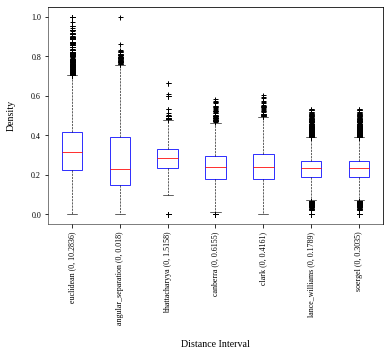

In [5]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# statistics
display(Markdown("<br>Statistics (*25th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (p25_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Density (*25th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **50th percentile distance intervals**

<br>Statistics (*50th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.0654)",20275,0.0,0.530915,0.174405,0.384615,0.515071,0.681818,1.000000,0.130876,2.024867
1,"bhattacharyya (0, 2.4304)",20275,0.0,0.537930,0.085609,0.485714,0.543743,0.594255,1.000000,-0.280338,3.697400
2,"canberra (0, 1.0142)",20275,0.0,0.460451,0.104524,0.397701,0.467836,0.525362,0.792161,-0.377849,3.900975
3,"clark (0, 0.6813)",20275,0.0,0.467909,0.107822,0.400000,0.482353,0.542484,0.813886,-0.563713,3.667925
4,"euclidean (0, 16.6132)",20275,0.0,0.598650,0.182721,0.458678,0.588933,0.723810,1.000000,0.265317,2.473189
5,"lance_williams (0, 0.3041)",20275,0.0,0.463858,0.090539,0.408974,0.452763,0.509804,1.000000,0.475927,4.098209
6,"soergel (0, 0.4664)",20275,0.0,0.463893,0.090547,0.409021,0.452763,0.509828,1.000000,0.475829,4.097847


<br>Graph Density (*50th percentile distance intervals*)

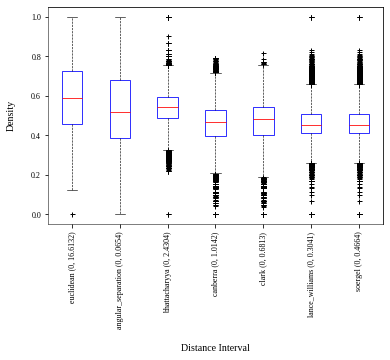

In [6]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

# statistics
display(Markdown("<br>Statistics (*50th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (p50_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Density (*50th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

#### **75th percentile distance intervals**

<br>Statistics (*75th percentile distance intervals*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.1799)",20275,0.0,0.754123,0.119872,0.669175,0.770563,0.847489,1.000000,-0.518979,3.102477
1,"bhattacharyya (0, 3.6452)",20275,0.0,0.776823,0.090969,0.721225,0.784211,0.846154,1.000000,-0.688528,3.818098
2,"canberra (0, 1.4712)",20275,0.0,0.690968,0.109509,0.623054,0.679924,0.763216,1.000000,-0.170402,4.119403
3,"clark (0, 0.983)",20275,0.0,0.688220,0.112330,0.628205,0.697044,0.758893,0.930149,-0.900938,5.513949
4,"euclidean (0, 26.242)",20275,0.0,0.833224,0.155897,0.725857,0.868421,0.974395,1.000000,-0.861941,3.095031
5,"lance_williams (0, 0.466)",20275,0.0,0.696886,0.107437,0.622572,0.666667,0.770229,1.000000,0.449977,2.967935
6,"soergel (0, 0.6357)",20275,0.0,0.696828,0.107424,0.622494,0.666667,0.770115,1.000000,0.449772,2.967148


<br>Graph Density (*75th percentile distance intervals*)

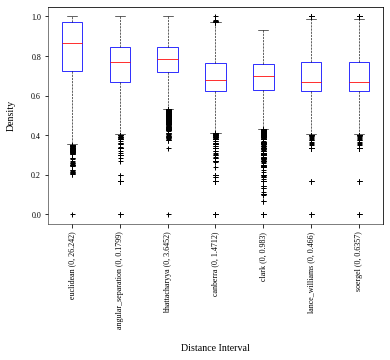

In [7]:
distance_intervals = [
    'euclidean (0, 26.242)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.466)',
    'soergel (0, 0.6357)'  
]

# statistics
display(Markdown("<br>Statistics (*75th percentile distance intervals*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_interval'].isin(distance_intervals)].reset_index(drop=True)[columns])

current_data = data[data['distance_interval'].isin(distance_intervals)].copy()  

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
# x_ticks = ['Euclidean', 'Bhattacharyya']
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (p75_distance_intervals) -histogram")
fig_size=(6, 4)
x_tick_rotation=90
y_lim=None

display(Markdown("<br>Graph Density (*75th percentile distance intervals*)"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, categories=distance_intervals, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Density Distribution (*per Distance Function*)**

#### **Euclidean**

<br>Statistics (*Euclidean*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"euclidean (0, 10.2836)",20275,0.0,0.341145,0.153752,0.226190,0.315966,0.417582,1.0,1.085044,4.360608
1,"euclidean (0, 16.6132)",20275,0.0,0.598650,0.182721,0.458678,0.588933,0.723810,1.0,0.265317,2.473189
2,"euclidean (0, 26.242)",20275,0.0,0.833224,0.155897,0.725857,0.868421,0.974395,1.0,-0.861941,3.095031


<br>*Graph Density (*Euclidean*)*

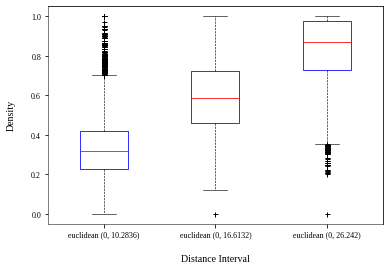

In [8]:
distance_function = 'euclidean'

# statistics
display(Markdown("<br>Statistics (*Euclidean*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (eu) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Euclidean*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Bhattacharyya**

<br>Statistics (*Bhattacharyya*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"bhattacharyya (0, 1.5158)",20275,0.0,0.286024,0.065410,0.234711,0.286765,0.333333,0.666667,0.097048,2.703761
1,"bhattacharyya (0, 2.4304)",20275,0.0,0.537930,0.085609,0.485714,0.543743,0.594255,1.000000,-0.280338,3.697400
2,"bhattacharyya (0, 3.6452)",20275,0.0,0.776823,0.090969,0.721225,0.784211,0.846154,1.000000,-0.688528,3.818098


<br>*Graph Density (*Bhattacharyya*)*

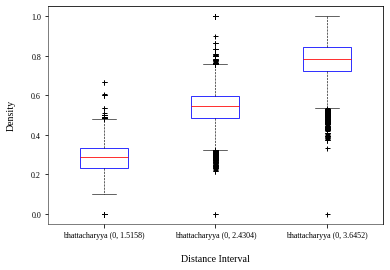

In [9]:
distance_function = 'bhattacharyya'

# statistics
display(Markdown("<br>Statistics (*Bhattacharyya*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (ba) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Bhattacharyya*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Canberra**

<br>Statistics (*Canberra*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"canberra (0, 0.6155)",20275,0.0,0.236074,0.080038,0.179487,0.241667,0.294118,0.581633,-0.141713,3.013838
1,"canberra (0, 1.0142)",20275,0.0,0.460451,0.104524,0.397701,0.467836,0.525362,0.792161,-0.377849,3.900975
2,"canberra (0, 1.4712)",20275,0.0,0.690968,0.109509,0.623054,0.679924,0.763216,1.000000,-0.170402,4.119403


<br>*Graph Density (*Canberra*)*

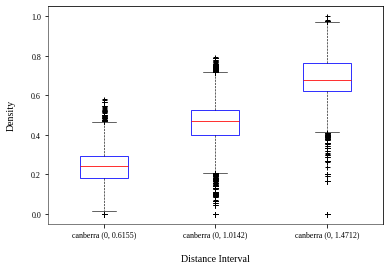

In [10]:
distance_function = 'canberra'

# statistics
display(Markdown("<br>Statistics (*Canberra*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (ca) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Canberra*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Clark**

<br>Statistics (*Clark*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"clark (0, 0.4161)",20275,0.0,0.240110,0.084857,0.177536,0.242347,0.304762,0.606293,-0.096509,2.755037
1,"clark (0, 0.6813)",20275,0.0,0.467909,0.107822,0.400000,0.482353,0.542484,0.813886,-0.563713,3.667925
2,"clark (0, 0.983)",20275,0.0,0.688220,0.112330,0.628205,0.697044,0.758893,0.930149,-0.900938,5.513949


<br>*Graph Density (*Clark*)*

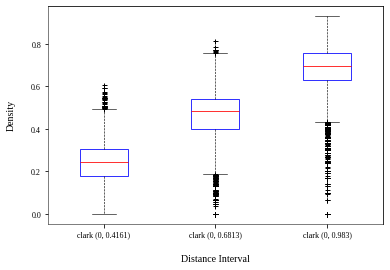

In [11]:
distance_function = 'clark'

# statistics
display(Markdown("<br>Statistics (*Clark*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (cl) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Clark*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Angular Separation**

<br>Statistics (*Angular Separation*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",20275,0.0,0.277599,0.161002,0.147992,0.231650,0.392372,1.0,0.757360,2.772130
1,"angular_separation (0, 0.0654)",20275,0.0,0.530915,0.174405,0.384615,0.515071,0.681818,1.0,0.130876,2.024867
2,"angular_separation (0, 0.1799)",20275,0.0,0.754123,0.119872,0.669175,0.770563,0.847489,1.0,-0.518979,3.102477


<br>*Graph Density (*Angular Separation*)*

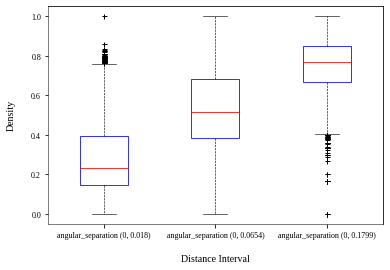

In [12]:
distance_function = 'angular_separation'

# statistics
display(Markdown("<br>Statistics (*Angular Separation*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (as) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Angular Separation*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Lance Williams**

<br>Statistics (*Lance Williams*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"lance_williams (0, 0.1789)",20275,0.0,0.232138,0.064296,0.190883,0.236782,0.271515,0.535615,-0.034051,4.186576
1,"lance_williams (0, 0.3041)",20275,0.0,0.463858,0.090539,0.408974,0.452763,0.509804,1.000000,0.475927,4.098209
2,"lance_williams (0, 0.466)",20275,0.0,0.696886,0.107437,0.622572,0.666667,0.770229,1.000000,0.449977,2.967935


<br>*Graph Density (*Lance Williams*)*

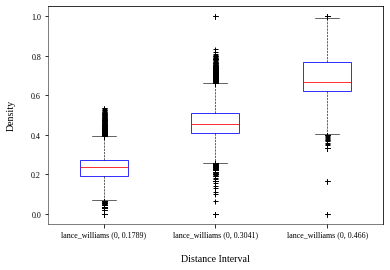

In [13]:
distance_function = 'lance_williams'

# statistics
display(Markdown("<br>Statistics (*Lance Williams*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (lw) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Lance Williams*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

#### **Soergel**

<br>Statistics (*Soergel*)

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"soergel (0, 0.3035)",20275,0.0,0.232133,0.064294,0.190883,0.236782,0.271506,0.535615,-0.034105,4.186613
1,"soergel (0, 0.4664)",20275,0.0,0.463893,0.090547,0.409021,0.452763,0.509828,1.000000,0.475829,4.097847
2,"soergel (0, 0.6357)",20275,0.0,0.696828,0.107424,0.622494,0.666667,0.770115,1.000000,0.449772,2.967148


<br>*Graph Density (*Soergel*)*

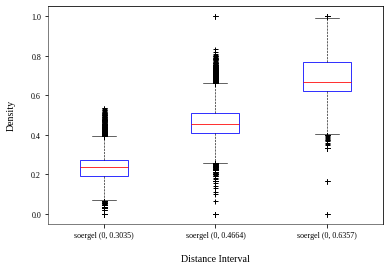

In [14]:
distance_function = 'soergel'

# statistics
display(Markdown("<br>Statistics (*Soergel*)"))
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics[statistics['distance_function'].isin([distance_function])].reset_index(drop=True)[columns])

current_data = data[(data['distance_function'] == distance_function)].copy()

# boxplot
x_axis = 'distance_interval'
y_axis = 'density'
x_label = 'Distance Interval'
y_label = 'Density'
output = paths['graph_metrics_path'].joinpath("Graph Density (so) -histogram")
fig_size=(6, 4)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Graph Density (*Soergel*)*"))
plt = boxplot(current_data, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

### **Analysis of Graph Density and Sequence Length Relationship (*per Distance Function*)**

#### **Euclidean**

<br>*Graph Density vs Sequence Length (*Euclidean*)*

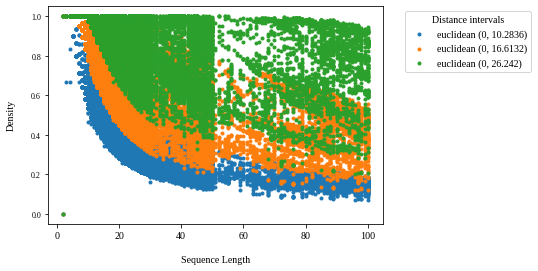

<br>*Graph Density vs Sequence Length - *euclidean (0, 10.2836)**

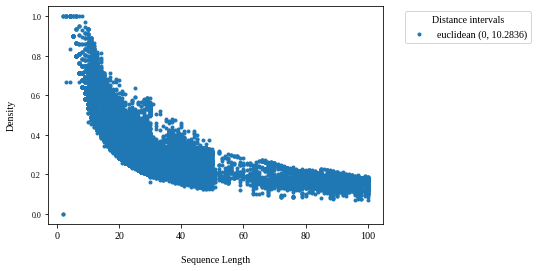

<br>*Graph Density vs Sequence Length - *euclidean (0, 16.6132)**

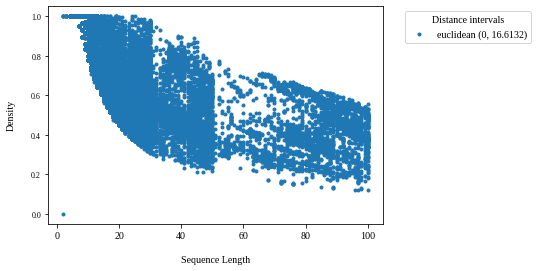

<br>*Graph Density vs Sequence Length - *euclidean (0, 26.242)**

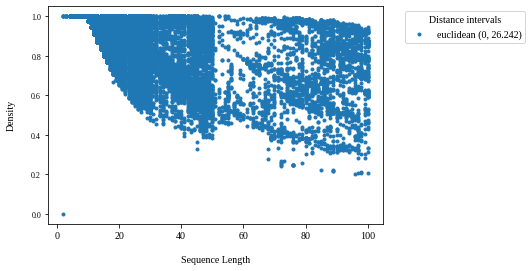

In [15]:
distance_function = 'euclidean'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Euclidean*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (eu) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 10.2836)
display(Markdown("<br>*Graph Density vs Sequence Length - *euclidean (0, 10.2836)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (eu_0_10) -scatter")
columns = ['euclidean (0, 10.2836)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 16.6132)
display(Markdown("<br>*Graph Density vs Sequence Length - *euclidean (0, 16.6132)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (eu_0_15) -scatter")
columns = ['euclidean (0, 16.6132)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# euclidean (0, 26.242)
display(Markdown("<br>*Graph Density vs Sequence Length - *euclidean (0, 26.242)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (eu_0_20) -scatter")
columns = ['euclidean (0, 26.242)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Bhattacharyya**

<br>*Graph Density vs Sequence Length (*Bhattacharyya*)*

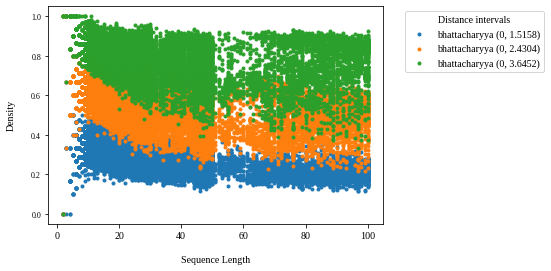

<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 1.5158)**

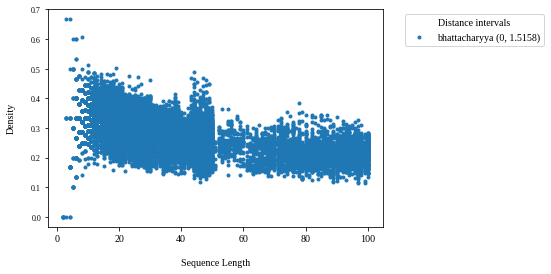

<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 2.4304)**

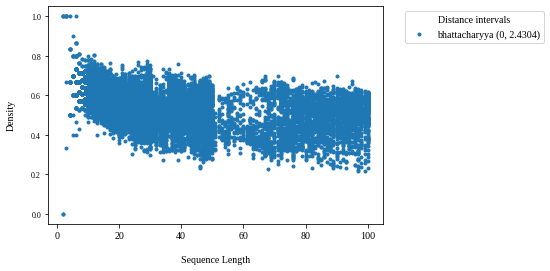

<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 3.6452)**

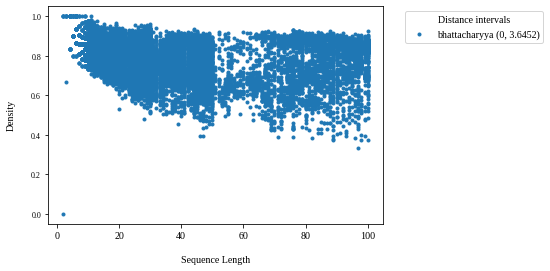

In [16]:
distance_function = 'bhattacharyya'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Bhattacharyya*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ba) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 1.5158)
display(Markdown("<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 1.5158)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ba_0_1.5158) -scatter")
columns = ['bhattacharyya (0, 1.5158)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 2.4304)
display(Markdown("<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 2.4304)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ba_0_2.4304) -scatter")
columns = ['bhattacharyya (0, 2.4304)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# bhattacharyya (0, 3.6452)
display(Markdown("<br>*Graph Density vs Sequence Length - *Bhattacharyya (0, 3.6452)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ba_0_3.6452) -scatter")
columns = ['bhattacharyya (0, 3.6452)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Canberra**

<br>*Graph Density vs Sequence Length (*Canberra*)*

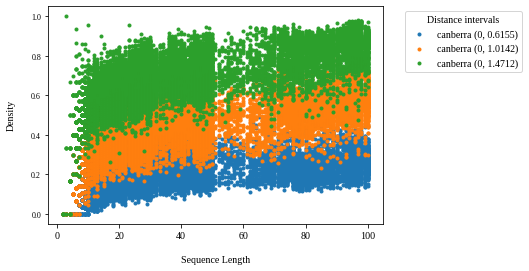

<br>*Graph Density vs Sequence Length - *Canberra (0, 0.6155)**

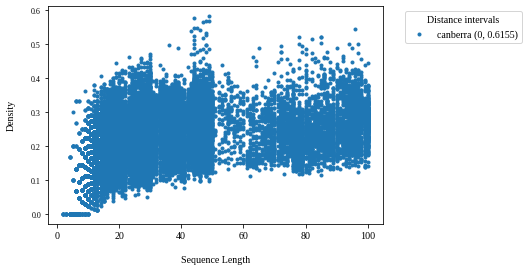

<br>*Graph Density vs Sequence Length - *Canberra (0, 1.0142)**

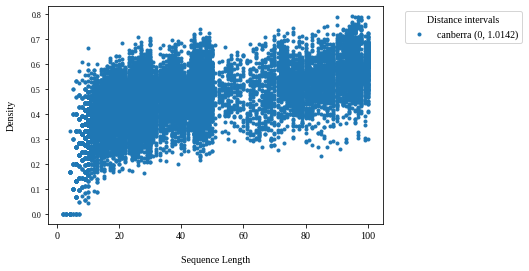

<br>*Graph Density vs Sequence Length - *Canberra (0, 1.4712)**

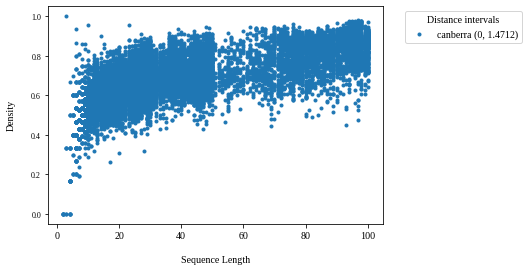

In [17]:
distance_function = 'canberra'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Canberra*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ca) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 1.5158)
display(Markdown("<br>*Graph Density vs Sequence Length - *Canberra (0, 0.6155)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ca_0_0.6155) -scatter")
columns = ['canberra (0, 0.6155)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 2.4304)
display(Markdown("<br>*Graph Density vs Sequence Length - *Canberra (0, 1.0142)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ca_0_1.0142) -scatter")
columns = ['canberra (0, 1.0142)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# canberra (0, 3.6452)
display(Markdown("<br>*Graph Density vs Sequence Length - *Canberra (0, 1.4712)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (ca_0_1.4712) -scatter")
columns = ['canberra (0, 1.4712)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Clark**

<br>*Graph Density vs Sequence Length (*Clark*)*

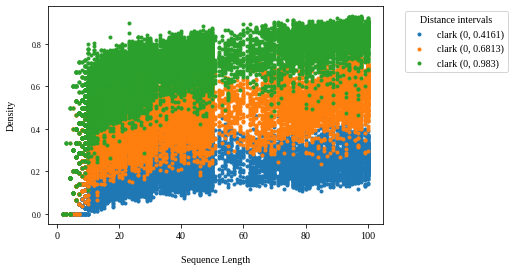

<br>*Graph Density vs Sequence Length - *Clark (0, 0.4161)**

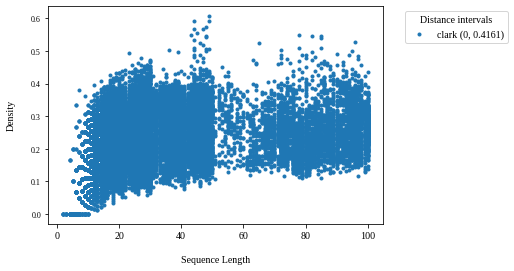

<br>*Graph Density vs Sequence Length - *Clark (0, 0.6813)**

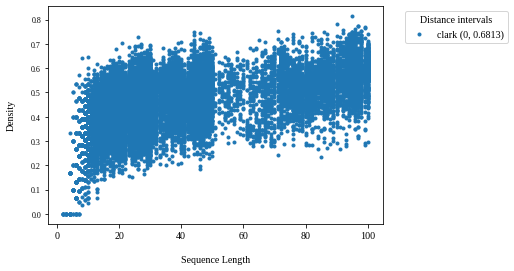

<br>*Graph Density vs Sequence Length - *Clark (0, 0.983)**

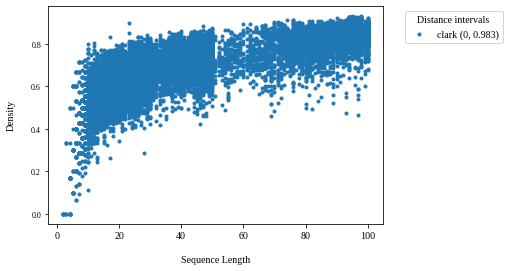

In [18]:
distance_function = 'clark'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Clark*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (cl) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 1.5158)
display(Markdown("<br>*Graph Density vs Sequence Length - *Clark (0, 0.4161)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (cl_0_0.4161) -scatter")
columns = ['clark (0, 0.4161)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.6813)
display(Markdown("<br>*Graph Density vs Sequence Length - *Clark (0, 0.6813)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (cl_0_0.6813) -scatter")
columns = ['clark (0, 0.6813)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# clark (0, 0.983)
display(Markdown("<br>*Graph Density vs Sequence Length - *Clark (0, 0.983)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (cl_0_0.983) -scatter")
columns = ['clark (0, 0.983)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Angular Separation**

<br>*Graph Density vs Sequence Length (*Angular Separation*)*

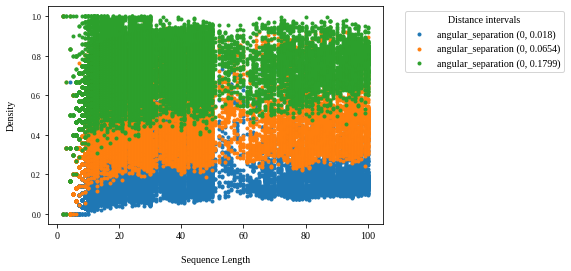

<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.018)**

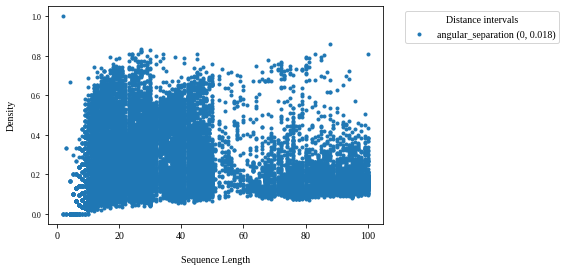

<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.0654)**

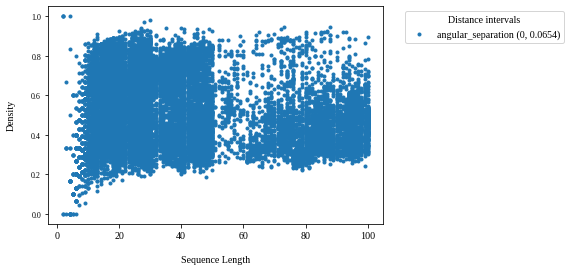

<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.1799)**

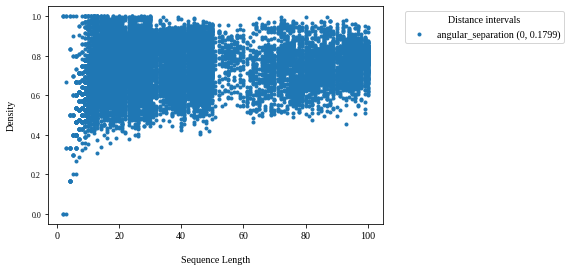

In [19]:
distance_function = 'angular_separation'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Angular Separation*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (as) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.018)
display(Markdown("<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.018)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (as_0_0.018) -scatter")
columns = ['angular_separation (0, 0.018)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.0654)
display(Markdown("<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.0654)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (as_0_0.0654) -scatter")
columns = ['angular_separation (0, 0.0654)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# angular_separation (0, 0.1799)
display(Markdown("<br>*Graph Density vs Sequence Length - *Angular Separation (0, 0.1799)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (as_0_0.1799) -scatter")
columns = ['angular_separation (0, 0.1799)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Lance Williams**

<br>*Graph Density vs Sequence Length (*Lance Williams*)*

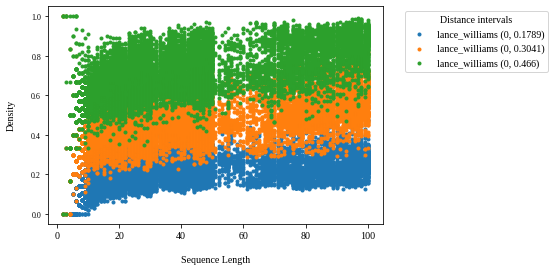

<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.1789)**

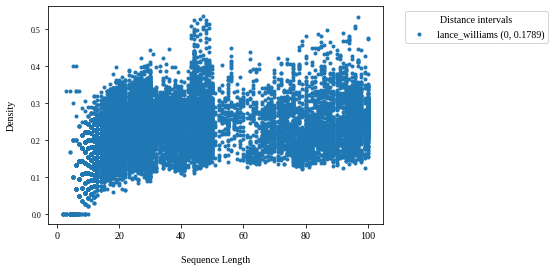

<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.3041)**

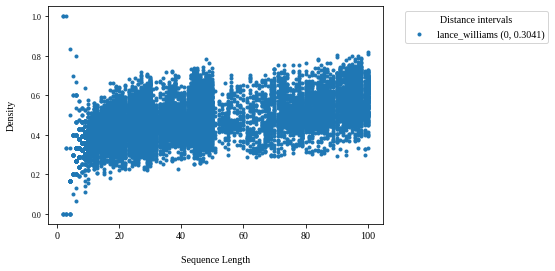

<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.4664)**

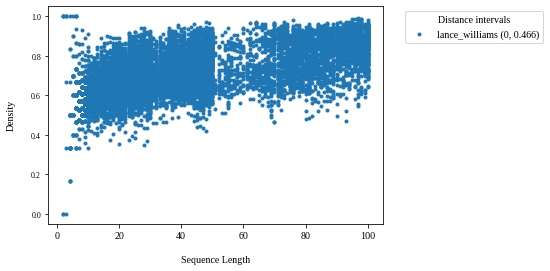

In [20]:
distance_function = 'lance_williams'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Lance Williams*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (lw) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.1789)
display(Markdown("<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.1789)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (lw_0_0.1789) -scatter")
columns = ['lance_williams (0, 0.1789)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.0654)
display(Markdown("<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.3041)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (lw_0_0.3041) -scatter")
columns = ['lance_williams (0, 0.3041)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# lance_williams (0, 0.466)
display(Markdown("<br>*Graph Density vs Sequence Length - *Lance Williams (0, 0.4664)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (lw_0_0.4664) -scatter")
columns = ['lance_williams (0, 0.466)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

#### **Soergel**

<br>*Graph Density vs Sequence Length (*Soergel*)*

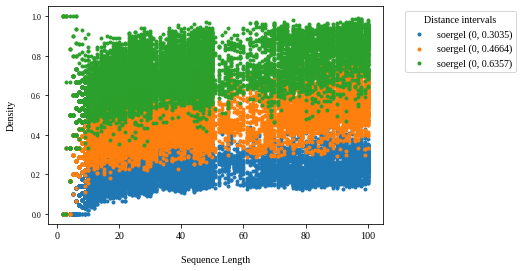

<br>*Graph Density vs Sequence Length - *Soergel (0, 0.3035)**

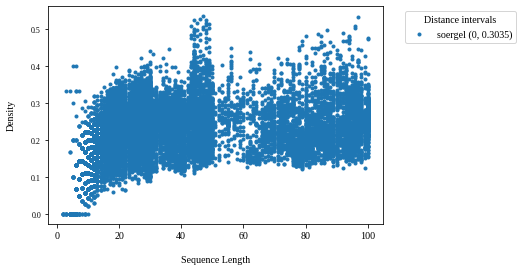

<br>*Graph Density vs Sequence Length - *Soergel (0, 0.4664)**

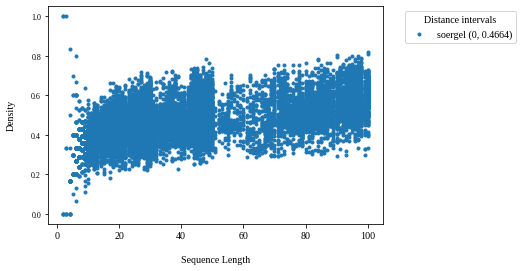

<br>*Graph Density vs Sequence Length - *Soergel (0, 0.6357)**

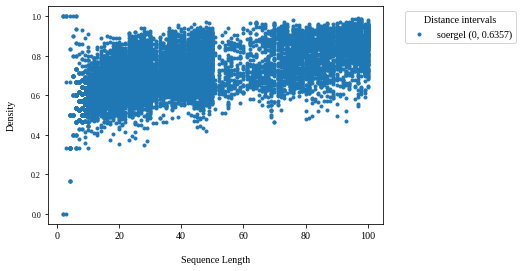

In [21]:
distance_function = 'soergel'
current_data = data[(data['distance_function'] == distance_function)].copy()

current_data_pivot = current_data.pivot_table(
    index='sequence',
    columns='distance_interval',
    values='density',
    observed=False
).reset_index()

current_data_pivot['number_of_nodes'] = current_data_pivot['sequence'].str.len()
current_data_pivot = current_data_pivot.sort_values(by='number_of_nodes')
current_data_pivot = current_data_pivot.drop(columns=['sequence'])

x_axis='number_of_nodes'
y_label = 'Graph Density'
x_label = 'Sequence Length'
y_label = 'Density'
legend_title='Distance intervals'
fig_size=(6, 4)

display(Markdown("<br>*Graph Density vs Sequence Length (*Soergel*)*"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (so) -scatter")
plt = scatter(current_data_pivot, x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.3035)
display(Markdown("<br>*Graph Density vs Sequence Length - *Soergel (0, 0.3035)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (so_0_0.3035) -scatter")
columns = ['soergel (0, 0.3035)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.4664)
display(Markdown("<br>*Graph Density vs Sequence Length - *Soergel (0, 0.4664)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (so_0_0.4664) -scatter")
columns = ['soergel (0, 0.4664)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()

# soergel (0, 0.6357)
display(Markdown("<br>*Graph Density vs Sequence Length - *Soergel (0, 0.6357)**"))
output = paths['graph_metrics_path'].joinpath("Graph Density vs Sequence Length (so_0_0.6357) -scatter")
columns = ['soergel (0, 0.6357)', 'number_of_nodes']
plt = scatter(current_data_pivot[columns], x_axis=x_axis, x_label=x_label, y_label=y_label, output=output, legend_title=legend_title, fig_size=fig_size)
plt.show()